# Jittering with 8 covariates

In [3]:
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import importlib
import gc
import tensorflow as tf
from tensorflow.keras import backend as K

!git clone https://github.com/Meowth239/dse4101-project.git
!git -C /content/dse4101-project checkout LSTM_r
import sys
sys.path.append('/content/dse4101-project/lstm_src')

import my_lstm
importlib.reload(my_lstm)

from my_lstm import build_lstm_model, create_sequences, expanding_window_lstm_forecast3

fatal: destination path 'dse4101-project' already exists and is not an empty directory.
Already on 'LSTM_r'
Your branch is up to date with 'origin/LSTM_r'.


In [4]:
#df = pd.read_csv('../data/final_data.csv')
df = pd.read_csv('/content/dse4101-project/data/final_data.csv')

df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1986-02-01,-0.001030,-0.001919,0.029004,-0.122803,-0.005468,-0.01,0.003518,0.000302,-0.394190
1,1986-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.003663,-0.50,0.007092,0.003699,-0.203766
2,1986-04-01,0.020833,-0.009353,0.060724,0.005213,0.001811,-0.50,-0.001419,0.001697,0.018075
3,1986-05-01,0.006006,-0.008792,0.009556,0.067115,0.006429,0.09,0.005246,0.000797,0.180503
4,1986-06-01,-0.054147,0.010266,-0.037406,0.144931,0.000907,0.06,-0.003911,-0.002716,-0.135577


In [5]:
feature_cols = [
    "AUD_USD_ret",
    "CAD_USD_ret",
    "NZD_USD_ret",
    "ZAR_USD_ret",
    "CPI",
    "TB3MS",
    "M1",
    "M2",
    "wti_ret"
]

target_col = "wti_ret"

In [6]:
df = df.sort_values("Date").reset_index(drop=True)

# compute indices based on original evaluation and test split
train_size = df.index[df["Date"] < "2014-02-01"][-1] + 1
val_end = df.index[df["Date"] <= "2020-01-01"][-1] + 1

# split using iloc
train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:val_end]
test_data = df.iloc[val_end:]

print(f"Train data length: {len(train_data)}")
print(f"Validation data length: {len(val_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 336
Validation data length: 72
Test data length: 72


In [7]:
param_grid_tiny = {
    "lookback": [2, 10],
    "dropout": [0.001, 0.1],
    "units": [50, 170],
    "epochs": [50, 100]
}

param_combinations = list(itertools.product(
    param_grid_tiny["lookback"],
    param_grid_tiny["dropout"],
    param_grid_tiny["units"],
    param_grid_tiny["epochs"]
))

results_grid = []
failed_combos = []

max_retries = 2

for i, (lb, dr, units, ep) in enumerate(param_combinations, 1):
    print(f"\n[{i}/{len(param_combinations)}] Testing params:")
    print(f"lookback={lb}, dropout={dr}, units={units}, epochs={ep}")

    success = False

    for attempt in range(1, max_retries + 1):
        try:
            print(f"Attempt {attempt}/{max_retries}")

            # clear memory before each attempt
            K.clear_session()
            tf.keras.backend.clear_session()
            gc.collect()

            val_forecasts = expanding_window_lstm_forecast3(
                df=df,
                feature_cols=feature_cols,
                target_col=target_col,
                initial_train_size=train_size,
                end_idx=val_end,
                date_col="Date",
                lookback=lb,
                units=units,
                dropout=dr,
                epochs=ep,
                batch_size=32,
                verbose=0,
                scale=True,
                seed=42,
                nojitter=False,          # use jitter
                jitter_std=0.03,
                jitter_cols=feature_cols,
                num_samples=1              # generate 1 sample
            )

            if len(val_forecasts) == 0:
                print("No forecasts generated.")
                raise ValueError("No forecasts generated")

            mse = mean_squared_error(
                val_forecasts["actual"],
                val_forecasts["predicted"]
            )

            print(f"Validation MSE: {mse:.6f}")

            results_grid.append({
                "lookback": lb,
                "dropout": dr,
                "units": units,
                "epochs": ep,
                "mse": mse,
                "attempt_used": attempt
            })

            success = True
            break

        except Exception as e:
            print(f"Error on attempt {attempt}: {e}")

            # clear memory after failure
            K.clear_session()
            tf.keras.backend.clear_session()
            gc.collect()

    if not success:
        print("Failed after all retries. Skipping this combination.")
        failed_combos.append({
            "lookback": lb,
            "dropout": dr,
            "units": units,
            "epochs": ep
        })

# --------------------------------------------------
# results
# --------------------------------------------------

results_grid_df = pd.DataFrame(results_grid).sort_values("mse").reset_index(drop=True)
failed_combos_df = pd.DataFrame(failed_combos)


[1/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=50
Attempt 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Validation MSE: 0.872428

[2/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=100
Attempt 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Validation MSE: 1.472057

[3/16] Testing params:
lookback=2, dropout=0.001, units=170, epochs=50
Attempt 1/2


...

Validation MSE: 0.695544

[15/16] Testing params:
lookback=10, dropout=0.1, units=170, epochs=50
Attempt 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Validation MSE: 0.575722

[16/16] Testing params:
lookback=10, dropout=0.1, units=170, epochs=100
Attempt 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Validation MSE: 0.606987


In [11]:
results_grid

[{'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.8724282994377621,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 1.472056855116169,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 50,
  'mse': 1.2826982352883667,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 100,
  'mse': 1.4490697723752204,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.5825479687149905,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.8690096863868201,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 50,
  'mse': 0.9627637053012208,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 1.0657262827619713,
  'attempt_used': 1},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 

In [18]:
from google.colab import drive
drive.mount('/content/drive')

import os

base_path = '/content/drive/MyDrive/dse4101'
os.makedirs(base_path, exist_ok=True)

print("Using path:", base_path)

results_path = os.path.join(base_path, 'results_grid_jitter.csv')
failed_path = os.path.join(base_path, 'failed_combos_jitter.csv')

pd.DataFrame(results_grid).to_csv(results_path, index=False)
pd.DataFrame(failed_combos).to_csv(failed_path, index=False)

print("Saved to:", results_path)


Mounted at /content/drive
Using path: /content/drive/MyDrive/dse4101
Saved to: /content/drive/MyDrive/dse4101/results_grid_jitter.csv


In [22]:
print("\nTop results:")
print(results_grid_df)

print("\nFailed combinations:")
print(failed_combos_df)


Top results:
    lookback  dropout  units  epochs       mse  attempt_used
0         10    0.100    170      50  0.575722             1
1          2    0.100     50      50  0.582548             1
2         10    0.100    170     100  0.606987             1
3         10    0.001    170     100  0.623158             1
4         10    0.001    170      50  0.628000             1
5         10    0.100     50      50  0.636781             1
6         10    0.100     50     100  0.695544             1
7         10    0.001     50      50  0.758247             1
8         10    0.001     50     100  0.791439             1
9          2    0.100     50     100  0.869010             1
10         2    0.001     50      50  0.872428             1
11         2    0.100    170      50  0.962764             1
12         2    0.100    170     100  1.065726             1
13         2    0.001    170      50  1.282698             1
14         2    0.001    170     100  1.449070             1
15        

In [23]:
best_params = results_grid_df.iloc[0]
best_lb = int(best_params["lookback"])
best_dr = float(best_params["dropout"])
best_units = int(best_params["units"])
best_ep = int(best_params["epochs"])

best_lb, best_dr, best_units, best_ep

(10, 0.1, 170, 50)

In [24]:
test_results = expanding_window_lstm_forecast3(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    initial_train_size=val_end,
    end_idx=len(df),
    date_col="Date",
    lookback=int(best_params["lookback"]),
    units=int(best_params["units"]),
    dropout=float(best_params["dropout"]),
    epochs=int(best_params["epochs"]),
    batch_size=32,
    verbose=0,
    scale=True,
    seed=42,
    nojitter=False,
    jitter_std=0.03,
    jitter_cols=feature_cols,
    num_samples=1            # generate 1 sample
)

test_mse = mean_squared_error(
    test_results["actual"],
    test_results["predicted"]
)

test_mape = mean_absolute_percentage_error(
    test_results["actual"],
    test_results["predicted"]
)

test_r2 = r2_score(
    test_results["actual"],
    test_results["predicted"]
)

print("Test MSE:", test_mse)
print("Test MAPE:", test_mape)
print("Test R²:", test_r2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Test MSE: 0.6019508796870761
Test MAPE: 22.525909361649415
Test R²: -30.768548033752126


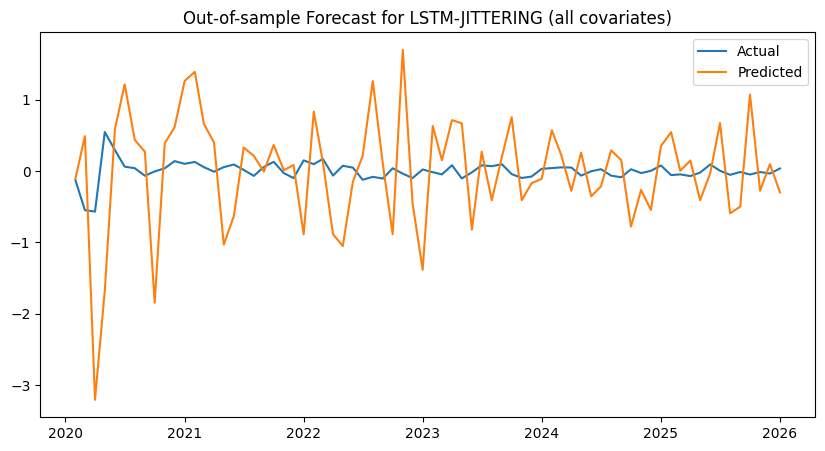

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test_results['Date'], test_results["actual"], label="Actual")
plt.plot(test_results['Date'], test_results["predicted"], label="Predicted")
plt.legend()
plt.title("Out-of-sample Forecast for LSTM-JITTERING (all covariates)")
plt.show()

In [26]:
# save results to csv
#test_results.to_csv('results/lstm-8-jitter_results.csv', index = False)

results_folder = os.path.join(base_path, 'results')
os.makedirs(results_folder, exist_ok=True)

# define file path
test_results_path = os.path.join(results_folder, 'lstm-8-jitter_results.csv')

# save
test_results.to_csv(test_results_path, index=False)

print("Saved to:", test_results_path)

Saved to: /content/drive/MyDrive/dse4101/results/lstm-8-jitter_results.csv
